# Extension: non-IID data, every attack type, and unseen devices

This notebook extends the federated anomaly detection project (see `nbaiot_full_pipeline.ipynb`
and the README). It is self-contained: it only needs the raw N-BaIoT files, not the output of the other notebook.

**Three questions**

1. **Non-IID.** The 4 devices have very different traffic and very different amounts of it. Does plain FedAvg suffer from that? Do FedProx, equal client weighting, or local scaling help?
2. **Attack coverage.** The first evaluation only used 4 of the 10 attack files per device. Does the model still do well on all 10?
3. **Unseen devices.** If a new device joins after training, does the global model still work on it?

**On "unseen attacks".** All models train on benign traffic only, so every attack is unseen at training time. The real gap in the first evaluation was coverage: 6 of the 10 attack types were never used for testing. Question 2 closes that gap.

**On "non-IID".** Because training uses benign data only, labels cannot be skewed across clients the way they are in a normal classification task. The skew that exists here is between devices: different feature scales, different traffic patterns, and very different data sizes (roughly 13k benign rows for the thermostat vs roughly 175k for the baby monitor).

**What differs from the main notebook**

- Local training uses real minibatches (batch size 256). The main notebook ran 5 full-batch gradient steps per round.
- Every result is averaged over 3 seeds, because at AUC close to 0.9999 a difference in the 4th decimal place can easily be noise.
- Besides ROC-AUC, it reports benign recall (TNR) and attack recall (TPR) at a threshold taken from each device's own benign training data.
- The federated loop is plain PyTorch instead of Flower simulation. It is the same algorithm (FedAvg) but faster to repeat many times and easy to swap for FedProx. The first federated row should land close to the Flower result as a sanity check.

## Setup

In [1]:
import os, copy, time, json, subprocess
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = "/content/data"
SAVE_DIR = "/content/drive/MyDrive/nbaiot-project/processed"

try:
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
except ImportError:
    pass
os.makedirs(SAVE_DIR, exist_ok=True)

# ---- experiment settings ----
ROUNDS = 10               # federated rounds
SEEDS = [0, 1, 2]         # every experiment is repeated for each seed
BATCH = 256
LR = 1e-3
MAX_ATTACK_ROWS = 20000   # cap per attack file, keeps memory small. AUC is stable at this size
print("device:", DEVICE)

Mounted at /content/drive
device: cpu


## Get the raw data

Same Kaggle download as the main notebook (about 1.75 GB). It needs a `KAGGLE_TOKEN` secret in Colab, and it is skipped if `/content/data` already exists.

In [2]:
if not os.path.exists(f"{DATA_DIR}/device_info.csv"):
    from google.colab import userdata
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    token_path = os.path.expanduser("~/.kaggle/access_token")
    with open(token_path, "w") as f:
        f.write(userdata.get("KAGGLE_TOKEN"))
    os.chmod(token_path, 0o600)
    subprocess.run("pip install -q kaggle", shell=True, check=True)
    subprocess.run("kaggle datasets download -d mkashifn/nbaiot-dataset -p /content", shell=True, check=True)
    subprocess.run(f"unzip -q -o /content/nbaiot-dataset.zip -d {DATA_DIR}", shell=True, check=True)
    print("downloaded")
else:
    print("data already there")

downloaded


## Load every attack type

Benign data is split 70/30 in file order, exactly like the main notebook, so train and test sets match. This time **all** attack files are loaded (up to 10 per device). Each file is capped at 20,000 random rows to keep memory low.

`ORIGINAL_ATTACKS` are the 4 types used in the first evaluation. The other 6 are new.

In [3]:
DEVICE_IDS = [1, 2, 4, 8]
DEVICE_NAMES = {
    1: "Danmini_Doorbell",
    2: "Ecobee_Thermostat",
    4: "Philips_B120N10_Baby_Monitor",
    8: "SimpleHome_XCS7_1002_WHT_Security_Camera",
}
SHORT = {
    "Danmini_Doorbell": "Doorbell",
    "Ecobee_Thermostat": "Thermostat",
    "Philips_B120N10_Baby_Monitor": "BabyMonitor",
    "SimpleHome_XCS7_1002_WHT_Security_Camera": "Camera",
}
GAFGYT = ["combo", "junk", "scan", "tcp", "udp"]
MIRAI = ["ack", "scan", "syn", "udp", "udpplain"]
ORIGINAL_ATTACKS = {"gafgyt_combo", "gafgyt_junk", "mirai_ack", "mirai_scan"}


def load_all(seed=42):
    rng = np.random.default_rng(seed)
    out = {}
    for did in DEVICE_IDS:
        name = DEVICE_NAMES[did]
        benign = pd.read_csv(f"{DATA_DIR}/{did}.benign.csv").values.astype(np.float32)
        n_train = int(len(benign) * 0.7)
        c = {"train": benign[:n_train], "test_benign": benign[n_train:], "attacks": {}}
        for fam, kinds in [("gafgyt", GAFGYT), ("mirai", MIRAI)]:
            for a in kinds:
                path = f"{DATA_DIR}/{did}.{fam}.{a}.csv"
                if not os.path.exists(path):
                    continue
                arr = pd.read_csv(path).values.astype(np.float32)
                if len(arr) > MAX_ATTACK_ROWS:
                    arr = arr[rng.choice(len(arr), MAX_ATTACK_ROWS, replace=False)]
                c["attacks"][f"{fam}_{a}"] = arr
        out[name] = c
    return out


clients = load_all()
NAMES = list(clients)
D = clients[NAMES[0]]["train"].shape[1]

rows = []
for n in NAMES:
    c = clients[n]
    rows.append({"device": SHORT[n], "benign_train": len(c["train"]),
                 "benign_test": len(c["test_benign"]), "attack_types": len(c["attacks"]),
                 "attack_rows": sum(len(v) for v in c["attacks"].values())})
pd.DataFrame(rows)

,device,benign_train,benign_test,attack_types,attack_rows
0,Doorbell,34683,14865,10,200000
1,Thermostat,9179,3934,10,200000
2,BabyMonitor,122667,52573,10,200000
3,Camera,32609,13976,10,200000


## Scaling

Two ways to standardize the features:

- **Shared scaler.** One mean and std for all devices, as in the main notebook. This does not require pooling raw data. Each client sends only its row count, sum, and sum of squares, and the server combines them into the same mean and std. No raw rows leave a device.
- **Local scaler.** Each device uses its own mean and std and shares nothing. This removes the offset between devices, but it can blow up features that barely move on one device.

In [4]:
def make_scaler(X):
    X = X.astype(np.float64)
    mean = X.mean(0)
    std = X.std(0)
    std[std < 1e-8] = 1.0
    return mean, std


def federated_scaler(names):
    """Combine per-client (count, sum, sum of squares). No raw rows are shared."""
    n, s, ss = 0, 0.0, 0.0
    for nm in names:
        X = clients[nm]["train"].astype(np.float64)
        n += len(X)
        s = s + X.sum(0)
        ss = ss + (X ** 2).sum(0)
    mean = s / n
    std = np.sqrt(np.maximum(ss / n - mean ** 2, 0))
    std[std < 1e-8] = 1.0
    return mean, std


def apply(scaler, X):
    mean, std = scaler
    return ((X - mean) / std).astype(np.float32)


SHARED = federated_scaler(NAMES)
SHARED_BY_CLIENT = {n: SHARED for n in NAMES}
LOCAL_BY_CLIENT = {n: make_scaler(clients[n]["train"]) for n in NAMES}

# sanity check: the federated scaler should match a scaler fit on pooled data
pooled = make_scaler(np.vstack([clients[n]["train"] for n in NAMES]))
print("max mean diff:", np.abs(SHARED[0] - pooled[0]).max() / (np.abs(pooled[0]).max() + 1e-12), "(relative)")

max mean diff: 1.631167677380544e-16 (relative)


## Model, local training, aggregation

Same autoencoder as before (115 -> 64 -> 16 -> 64 -> 115). Local training has an optional FedProx term that adds `(mu/2) * ||w - w_global||^2` to the loss. It pulls each client back toward the global model and limits client drift.

In [5]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 64), nn.ReLU(),
                                     nn.Linear(64, latent_dim), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(latent_dim, 64), nn.ReLU(),
                                     nn.Linear(64, input_dim))
    def forward(self, x):
        return self.decoder(self.encoder(x))


def set_seed(s):
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)


def to_tensor(X):
    return torch.from_numpy(X).to(DEVICE)


def local_train(model, X, epochs=1, mu=0.0, global_params=None):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    n = X.size(0)
    for _ in range(epochs):
        perm = torch.randperm(n, device=X.device)
        for i in range(0, n, BATCH):
            b = X[perm[i:i + BATCH]]
            opt.zero_grad()
            loss = ((model(b) - b) ** 2).mean()
            if mu > 0:
                prox = sum(((p - g) ** 2).sum() for p, g in zip(model.parameters(), global_params))
                loss = loss + (mu / 2) * prox
            loss.backward()
            opt.step()


def aggregate(states, weights):
    w = np.asarray(weights, dtype=np.float64)
    w = w / w.sum()
    return {k: sum(float(wi) * s[k].float() for wi, s in zip(w, states)) for k in states[0]}


@torch.no_grad()
def recon_error(model, X, chunk=65536):
    model.eval()
    out = []
    for i in range(0, len(X), chunk):
        xb = to_tensor(X[i:i + chunk])
        out.append(((model(xb) - xb) ** 2).mean(1).cpu().numpy())
    return np.concatenate(out)

## Training setups

- `run_federated`: FedAvg or FedProx over the given clients.
- `run_local_only`: each device trains its own model and shares nothing.
- `run_centralized`: all data pooled on one machine. This is the ceiling.

In [6]:
def run_federated(train_names, scalers, local_epochs=1, mu=0.0, weighting="size", rounds=ROUNDS, seed=0):
    set_seed(seed)
    data = {n: to_tensor(apply(scalers[n], clients[n]["train"])) for n in train_names}
    gmodel = Autoencoder(D).to(DEVICE)
    for _ in range(rounds):
        gstate = copy.deepcopy(gmodel.state_dict())
        gparams = [p.detach().clone() for p in gmodel.parameters()]
        states, sizes = [], []
        for n in train_names:
            local = Autoencoder(D).to(DEVICE)
            local.load_state_dict(gstate)
            local_train(local, data[n], local_epochs, mu=mu, global_params=gparams)
            states.append({k: v.detach().clone() for k, v in local.state_dict().items()})
            sizes.append(len(data[n]))
        w = sizes if weighting == "size" else [1] * len(sizes)
        gmodel.load_state_dict(aggregate(states, w))
    return gmodel


def run_local_only(names, scalers, epochs, seed=0):
    set_seed(seed)
    models = {}
    for n in names:
        m = Autoencoder(D).to(DEVICE)
        local_train(m, to_tensor(apply(scalers[n], clients[n]["train"])), epochs)
        models[n] = m
    return models


def run_centralized(names, scaler, epochs, seed=0):
    set_seed(seed)
    X = to_tensor(np.vstack([apply(scaler, clients[n]["train"]) for n in names]))
    m = Autoencoder(D).to(DEVICE)
    local_train(m, X, epochs)
    return m

## Evaluation

For each device:

- **AUC:** benign test rows vs all attack rows of that device (all attack types pooled).
- **TNR:** share of benign test rows correctly called benign.
- **TPR:** share of attack rows correctly caught.
- The threshold is the 95th percentile of the device's own benign **training** error, so it needs no attack labels and no data from other devices.
- Also returns AUC for each attack type separately, for the per-attack heatmap.

In [7]:
def evaluate(model, name, scaler):
    c = clients[name]
    thr = np.percentile(recon_error(model, apply(scaler, c["train"])), 95)
    err_b = recon_error(model, apply(scaler, c["test_benign"]))
    per_attack, errs = {}, []
    for a, X in c["attacks"].items():
        e = recon_error(model, apply(scaler, X))
        y = np.r_[np.zeros(len(err_b)), np.ones(len(e))]
        per_attack[a] = float(roc_auc_score(y, np.r_[err_b, e]))
        errs.append(e)
    e_all = np.concatenate(errs)
    y = np.r_[np.zeros(len(err_b)), np.ones(len(e_all))]
    return {"auc": float(roc_auc_score(y, np.r_[err_b, e_all])),
            "tnr": float((err_b <= thr).mean()),
            "tpr": float((e_all > thr).mean()),
            "per_attack": per_attack}

## Experiment 1: non-IID, methods compared

Each row is one way of training. All are evaluated per device on all attack types.

| Method | What it tests |
|---|---|
| centralized (pooled) | Ceiling: all data in one place |
| local only | What you get with no federation at all |
| FedAvg, 1 local epoch | The main federated setup, should match the main notebook |
| FedAvg, equal weights | FedAvg weights clients by data size, so the baby monitor dominates. Does that matter? |
| FedAvg, 5 local epochs | More local training means more client drift when devices differ |
| FedProx, 5 local epochs | Same as above plus the proximal term |
| FedAvg, local scalers | No shared statistics at all |

7 setups x 3 seeds. On a CPU runtime this takes roughly 10 to 25 minutes (a rough estimate).

In [9]:
EXPERIMENTS = {
    "centralized (pooled)":        dict(kind="central"),
    "local only":                  dict(kind="local"),
    "FedAvg, 1 local epoch":       dict(kind="fed", E=1, mu=0.0, weighting="size",    scalers="shared"),
    "FedAvg, equal weights":       dict(kind="fed", E=1, mu=0.0, weighting="uniform", scalers="shared"),
    "FedAvg, 5 local epochs":      dict(kind="fed", E=5, mu=0.0, weighting="size",    scalers="shared"),
    "FedProx (mu=0.1), 5 epochs":  dict(kind="fed", E=5, mu=0.1, weighting="size",    scalers="shared"),
    "FedAvg, local scalers":       dict(kind="fed", E=1, mu=0.0, weighting="size",    scalers="local"),
}

results = {}   # results[method][seed][device] = metrics
for method, cfg in EXPERIMENTS.items():
    results[method] = {}
    t0 = time.time()
    for seed in SEEDS:
        if cfg["kind"] == "central":
            m = run_centralized(NAMES, SHARED, epochs=ROUNDS, seed=seed)
            res = {n: evaluate(m, n, SHARED) for n in NAMES}
        elif cfg["kind"] == "local":
            ms = run_local_only(NAMES, SHARED_BY_CLIENT, epochs=ROUNDS, seed=seed)
            res = {n: evaluate(ms[n], n, SHARED) for n in NAMES}
        else:
            sc = SHARED_BY_CLIENT if cfg["scalers"] == "shared" else LOCAL_BY_CLIENT
            m = run_federated(NAMES, sc, cfg["E"], cfg["mu"], cfg["weighting"], seed=seed)
            res = {n: evaluate(m, n, sc[n]) for n in NAMES}
        results[method][seed] = res
    print(f"{method:32s} done in {time.time() - t0:5.0f}s")

centralized (pooled)             done in    56s
local only                       done in    45s
FedAvg, 1 local epoch            done in    46s
FedAvg, equal weights            done in    45s
FedAvg, 5 local epochs           done in   207s
FedProx (mu=0.1), 5 epochs       done in   264s
FedAvg, local scalers            done in    46s


### Summary table

Mean over the 4 devices, then mean and standard deviation over seeds. `1 - AUC` is shown because the AUCs are all so close to 1 that the error is easier to compare.

In [10]:
def seed_stats(method, metric):
    per_seed = [np.mean([results[method][s][n][metric] for n in NAMES]) for s in SEEDS]
    return np.mean(per_seed), np.std(per_seed)

rows = []
for method in EXPERIMENTS:
    auc_m, auc_s = seed_stats(method, "auc")
    tnr_m, tnr_s = seed_stats(method, "tnr")
    tpr_m, tpr_s = seed_stats(method, "tpr")
    rows.append({"method": method,
                 "AUC": f"{auc_m:.5f} +- {auc_s:.5f}",
                 "1 - AUC": f"{1 - auc_m:.2e}",
                 "benign recall (TNR)": f"{tnr_m:.3f} +- {tnr_s:.3f}",
                 "attack recall (TPR)": f"{tpr_m:.3f} +- {tpr_s:.3f}"})
summary_df = pd.DataFrame(rows).set_index("method")
summary_df

,AUC,1 - AUC,benign recall (TNR),attack recall (TPR)
method,,,,
centralized (pooled),0.98768 +- 0.00218,1.23e-02,0.948 +- 0.001,0.883 +- 0.024
local only,0.99101 +- 0.00247,8.99e-03,0.945 +- 0.001,0.950 +- 0.041
"FedAvg, 1 local epoch",0.95065 +- 0.02461,4.94e-02,0.944 +- 0.002,0.883 +- 0.024
"FedAvg, equal weights",0.94198 +- 0.01175,5.80e-02,0.947 +- 0.001,0.850 +- 0.000
"FedAvg, 5 local epochs",0.93258 +- 0.00497,6.74e-02,0.945 +- 0.001,0.883 +- 0.024
"FedProx (mu=0.1), 5 epochs",0.99591 +- 0.00133,4.09e-03,0.951 +- 0.000,0.966 +- 0.024
"FedAvg, local scalers",0.99351 +- 0.00043,6.49e-03,0.948 +- 0.001,0.950 +- 0.000


### Per device (AUC, mean over seeds)

,Doorbell,Thermostat,BabyMonitor,Camera,mean
centralized (pooled),0.99768,0.97811,0.98895,0.98599,0.98768
local only,0.99905,0.97943,0.99520,0.99036,0.99101
"FedAvg, 1 local epoch",0.99791,0.89744,0.99056,0.91668,0.95065
"FedAvg, equal weights",0.99711,0.86597,0.96894,0.93589,0.94198
"FedAvg, 5 local epochs",0.99718,0.85685,0.98946,0.88684,0.93258
"FedProx (mu=0.1), 5 epochs",0.99906,0.99935,0.99713,0.98809,0.99591
"FedAvg, local scalers",0.99811,0.99678,0.99743,0.98171,0.99351


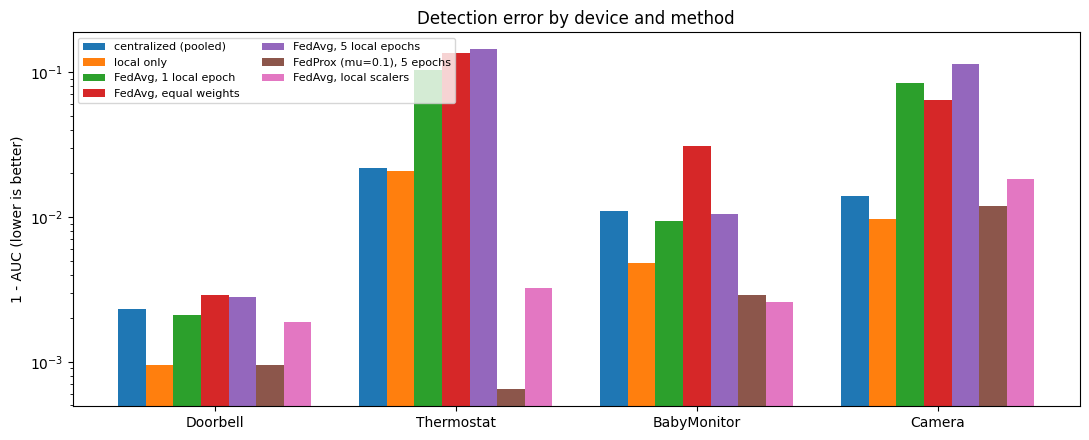

In [11]:
per_dev = pd.DataFrame(
    {SHORT[n]: {m: np.mean([results[m][s][n]["auc"] for s in SEEDS]) for m in EXPERIMENTS} for n in NAMES}
)
per_dev["mean"] = per_dev.mean(axis=1)
display(per_dev.style.format("{:.5f}"))

# plot the error (1 - AUC) on a log axis so small differences are visible. lower is better
fig, ax = plt.subplots(figsize=(11, 4.5))
width = 0.8 / len(EXPERIMENTS)
x = np.arange(len(NAMES))
for i, m in enumerate(EXPERIMENTS):
    vals = [max(1 - per_dev.loc[m, SHORT[n]], 1e-7) for n in NAMES]
    ax.bar(x + i * width, vals, width, label=m)
ax.set_xticks(x + width * (len(EXPERIMENTS) - 1) / 2)
ax.set_xticklabels([SHORT[n] for n in NAMES])
ax.set_yscale("log")
ax.set_ylabel("1 - AUC (lower is better)")
ax.set_title("Detection error by device and method")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### How to read the results

- **Sanity check:** `FedAvg, 1 local epoch` should be close to the 0.9999 from the main notebook. If it is far off, suspect the setup, not federated learning.
- Compare methods using the `+-` column. If two methods differ by less than the seed standard deviation, treat them as tied.
- **Local only vs FedAvg** shows what federation buys. **Pooled vs FedAvg** shows what it costs.
- Check TNR too. AUC can be near 1 while 5 to 10 percent of normal traffic is still flagged.

## Experiment 2: every attack type

Per-attack AUC for the main federated model (`FedAvg, 1 local epoch`), averaged over seeds. Columns marked with `*` are the 6 attack types the first evaluation never tested.

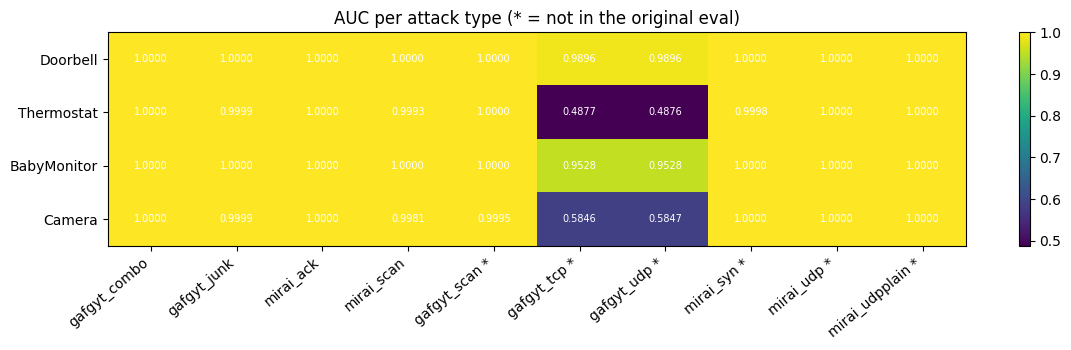

,original 4 attacks (mean AUC),6 new attacks (mean AUC),worst single attack,worst attack name
Doorbell,0.999998,0.996517,0.989551,gafgyt_udp
Thermostat,0.999811,0.829188,0.487647,gafgyt_udp
BabyMonitor,0.999991,0.984277,0.952831,gafgyt_udp
Camera,0.999488,0.861471,0.584647,gafgyt_tcp


In [12]:
MAIN = "FedAvg, 1 local epoch"
attack_types = sorted({a for n in NAMES for a in clients[n]["attacks"]})
attack_types = sorted(attack_types, key=lambda a: (a not in ORIGINAL_ATTACKS, a))
per_attack_df = pd.DataFrame(
    {a: {SHORT[n]: np.mean([results[MAIN][s][n]["per_attack"].get(a, np.nan) for s in SEEDS]) for n in NAMES}
     for a in attack_types}
)
labels = [a + ("" if a in ORIGINAL_ATTACKS else " *") for a in attack_types]

fig, ax = plt.subplots(figsize=(12, 3.6))
vals = per_attack_df.values.astype(float)
im = ax.imshow(vals, aspect="auto", cmap="viridis", vmin=np.nanmin(vals), vmax=1.0)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=40, ha="right")
ax.set_yticks(range(len(per_attack_df.index)))
ax.set_yticklabels(per_attack_df.index)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        if not np.isnan(vals[i, j]):
            ax.text(j, i, f"{vals[i, j]:.4f}", ha="center", va="center", fontsize=7, color="white")
ax.set_title("AUC per attack type (* = not in the original eval)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

orig_cols = [a for a in attack_types if a in ORIGINAL_ATTACKS]
new_cols = [a for a in attack_types if a not in ORIGINAL_ATTACKS]
coverage = pd.DataFrame({
    "original 4 attacks (mean AUC)": per_attack_df[orig_cols].mean(axis=1),
    "6 new attacks (mean AUC)": per_attack_df[new_cols].mean(axis=1),
    "worst single attack": per_attack_df.min(axis=1),
    "worst attack name": per_attack_df.idxmin(axis=1),
})
coverage

## Experiment 3: a device the federation never saw

Leave one device out: train FedAvg on the other 3 devices only, then test on the 4th.

Two ways the new device can be normalized when it joins:

- **Fleet scaler:** reuse the mean and std from the 3 training devices (no setup on the new device).
- **Own scaler:** the new device computes its own mean and std from its first benign traffic (a normal onboarding step).

The threshold always comes from the new device's own benign training rows.

In [13]:
lodo_rows = []
for held in NAMES:
    others = [n for n in NAMES if n != held]
    fleet = federated_scaler(others)
    sc = {n: fleet for n in others}
    a_fleet, a_own, t_fleet, t_own = [], [], [], []
    for seed in SEEDS:
        m = run_federated(others, sc, 1, 0.0, "size", seed=seed)
        r1 = evaluate(m, held, fleet)
        r2 = evaluate(m, held, LOCAL_BY_CLIENT[held])
        a_fleet.append(r1["auc"]); t_fleet.append(r1["tnr"])
        a_own.append(r2["auc"]);   t_own.append(r2["tnr"])
    in_fed = np.mean([results[MAIN][s][held]["auc"] for s in SEEDS])
    lodo_rows.append({
        "held-out device": SHORT[held],
        "AUC when it was in the federation": in_fed,
        "AUC unseen, fleet scaler": np.mean(a_fleet),
        "AUC unseen, own scaler": np.mean(a_own),
        "TNR unseen, fleet scaler": np.mean(t_fleet),
        "TNR unseen, own scaler": np.mean(t_own),
    })
    print("done:", SHORT[held])
lodo_df = pd.DataFrame(lodo_rows).set_index("held-out device")
lodo_df.style.format("{:.5f}")

done: Doorbell
done: Thermostat
done: BabyMonitor
done: Camera


,AUC when it was in the federation,"AUC unseen, fleet scaler","AUC unseen, own scaler","TNR unseen, fleet scaler","TNR unseen, own scaler"
held-out device,,,,,
Doorbell,0.99791,0.99738,0.99645,0.93430,0.94011
Thermostat,0.89744,0.86162,0.98549,0.94069,0.95204
BabyMonitor,0.99056,0.92299,0.98198,0.95172,0.95350
Camera,0.91668,0.87823,0.98142,0.94970,0.95261


## Save results

In [14]:
summary_df.to_csv(os.path.join(SAVE_DIR, "ext_method_summary.csv"))
per_dev.to_csv(os.path.join(SAVE_DIR, "ext_per_device_auc.csv"))
per_attack_df.to_csv(os.path.join(SAVE_DIR, "ext_per_attack_auc.csv"))
lodo_df.to_csv(os.path.join(SAVE_DIR, "ext_unseen_device.csv"))
print("saved 4 csv files to", SAVE_DIR)

saved 4 csv files to /content/drive/MyDrive/nbaiot-project/processed


## Findings

Results from one full run: 3 seeds, 10 rounds, all 10 attack types per device. Mean AUC is over the 4 devices unless stated.

| Question | Result |
|---|---|
| Non-IID: best method vs `FedAvg, 1 local epoch` (beyond seed spread?) | Yes. FedProx (5 epochs) scores 0.9959 +- 0.0013 and FedAvg with local scalers scores 0.9935 +- 0.0004, against 0.9507 +- 0.0246 for plain FedAvg. The gap of about 0.04 is much bigger than the seed spread. FedProx, local scalers and local only (0.9910 +- 0.0025) are close to each other, so I treat them as tied. |
| Non-IID: effect of 5 local epochs, and did FedProx fix it? | 5 local epochs scored 0.9326 +- 0.0050, a little lower than 1 epoch, but within its large seed spread, so not clearly worse. FedProx with the same 5 epochs reached 0.9959, so yes, it fixed it. The thermostat went from 0.857 to 0.999. |
| Non-IID: did equal weighting help the small devices? | No. Equal weights scored 0.9420 +- 0.0118, the same as plain FedAvg within noise. The thermostat did not improve (0.866 vs 0.897). Data size imbalance alone does not look like the cause. Local scaling fixing it points to differences in feature scale between devices, but this is a guess I have not tested directly. |
| Federation value: local only vs FedAvg vs pooled | Local only 0.9910, pooled 0.9877, plain FedAvg 0.9507. Once device differences are handled, federation matches or slightly beats local only (FedProx 0.9959, local scalers 0.9935), so the gain is small here. Pooled scored below local only, probably because one small autoencoder has to model four very different devices. |
| Attack coverage: mean AUC on the 6 new attacks vs the original 4 (`FedAvg, 1 local epoch`) | Original 4: 0.9995 to 1.0000 on every device. New 6: Doorbell 0.9965, Baby Monitor 0.9843, Camera 0.8615, Thermostat 0.8292. Almost all of the drop comes from two attack types, `gafgyt_tcp` and `gafgyt_udp`. The other 8 types score about 1.00 on every device. |
| Attack coverage: worst attack per device | `gafgyt_udp` for Doorbell (0.9896), Thermostat (0.4876) and Baby Monitor (0.9528). `gafgyt_tcp` for Camera (0.5846). An AUC near 0.5 is a coin flip. The tcp and udp results match to 3 or 4 decimals on every device, which suggests those two attack files look almost the same in this feature space. I have not checked this directly. |
| Unseen device: AUC drop, and does the own scaler recover it? | With the fleet scaler: Doorbell 0.9974, Thermostat 0.8616, Baby Monitor 0.9230, Camera 0.8782. With its own scaler: 0.9965, 0.9855, 0.9820, 0.9814. The own scaler recovers almost everything. Note that the "in federation" column in the table above used plain FedAvg with the shared scaler, which is the weak setup, so it is not a clean comparison. |
| Benign recall (TNR) when AUC is near 1 | TNR is 0.94 to 0.95 for every method. That is by construction, because the threshold is the 95th percentile of benign training error, so it says nothing about the model. Attack recall (TPR) varies more, from 0.85 (equal weights) to 0.966 (FedProx). |

**Main takeaway.** The first result (0.99998 AUC, federated matches centralized) only held on 4 easy attack types. On all 10 types, plain FedAvg with a shared scaler is clearly worse, especially on the thermostat and camera. Handling device differences, either with local scalers or with FedProx, brings it back to about 0.994 to 0.996. A new device works well if it computes its own scaler.

**Limitations**

- Only 3 seeds, so the order of the top three methods is not settled.
- The cause of the plain FedAvg failure is a hypothesis. No test isolates it.
- The tcp and udp attacks may be near duplicates. Not checked.
- Federated training is still simulated on one machine, so there is no network delay or dropped clients.
- Attack files are subsampled to 20,000 rows each.
- Only 4 of the 9 N-BaIoT devices are used.

**Not done here:** comparing FedAvg with a robust aggregator (median or trimmed mean) when one client sends poisoned updates.